# Advanced Disk Modeling

In [1]:
import os
os.environ["WEBBPSF_PATH"] = 'stpsf-data'
os.environ["WEBBPSF_EXT_PATH"] = 'stpsf-data'
os.environ["PYSYN_CDBS"] = "cdbs"

from astropy.io import fits

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.40'

jax.config.update("jax_enable_x64", True)

#### Loading Files

In [2]:
# GPI Image Initial Parameter Reference

# Name             Radius   Inclination  Position Angle Distance  Knots                                                  
# hd111161_H_pol    72.4         62.1        263.2        109.43      5
# hr4796a_H_pol     78.5         76.5         26.1         72.78      7
# hd115600_H_pol	46.0	     80.0	      27.5	      109.62	  5

row = {'Name': 'hd115600_H_pol', 'Radius': 46.0, 'Inclination': 80.0, "Position Angle": 27.5, "Distance": 109.62, "Knots": 5}


### Processing Fits File

2025-10-29 01:19:26.596514: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Filename: test_images/hd115600_H_pol.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     523   ()      
  1  SCI           1 ImageHDU       142   (281, 281, 4)   float32   
  2  DQ            3 ImageHDU        64   (281, 281, 2)   uint8   


Text(0.5, 1.0, 'Image from Fits File')

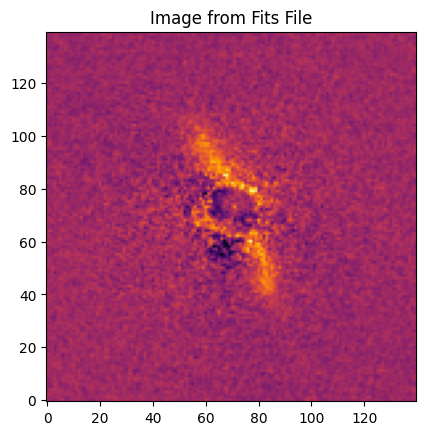

In [3]:
from grater_jax.optimization.optimize_framework import OptimizeUtils

fits_image_filepath = "test_images/" + row['Name'] + ".fits"
hdul = fits.open(fits_image_filepath)

#Displays File Info
hdul.info()

# Gets Image
target_image = OptimizeUtils.process_image(hdul['SCI'].data[1,:,:], bounds=(70, 210, 70, 210))

# Displays Image
plt.imshow(target_image, origin='lower', cmap='inferno')
plt.title("Image from Fits File")

## Getting Optimal Disk Fit

In [4]:
from grater_jax.optimization.optimize_framework import Optimizer, OptimizeUtils
from grater_jax.disk_model.objective_functions import objective_model, objective_ll, objective_fit, Parameter_Index
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
from grater_jax.disk_model.SLD_utils import *

### Initializing Relevant Parameters

In [5]:
target_image = OptimizeUtils.process_image(hdul['SCI'].data[1,:,:], bounds=(70, 210, 70, 210))
err_map = OptimizeUtils.process_image(OptimizeUtils.create_empirical_err_map(hdul['SCI'].data[2,:,:]), bounds=(70, 210, 70, 210)) #, outlier_pixels=[(57, 68)]))

/home/mihirkondapalli/anaconda3/envs/package-env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [6]:
scale_factor = 1
image = fits.open("PSFs/GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

In [7]:
from grater_jax.disk_model.SLD_utils import *

In [8]:
start_disk_params = Parameter_Index.disk_params.copy()
start_spf_params = InterpolatedUnivariateSpline_SPF.params.copy()
start_psf_params = EMP_PSF.params.copy()
start_stellar_psf_params = LinearStellarPSF.params.copy()
start_misc_params = Parameter_Index.misc_params.copy()

start_disk_params = Parameter_Index.disk_params.copy()
start_disk_params['sma'] = row["Radius"]
start_disk_params['inclination'] = row["Inclination"]
start_disk_params['position_angle'] = row["Position Angle"]

start_spf_params['num_knots'] = int(row["Knots"])

start_misc_params['distance'] = row["Distance"]
start_misc_params['nx'] = 140
start_misc_params['ny'] = 140

start_disk_params['x_center'] = start_misc_params['nx']/2
start_disk_params['y_center'] = start_misc_params['ny']/2

opt = Optimizer(ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, EMP_PSF,
                start_disk_params, start_spf_params, start_psf_params, start_misc_params)

opt.inc_bound_knots() # call this method only if you have a good predifined inclination, otherwise don't use it
opt.set_empirical_psf(emp_psf_image) # <-- Only necessary if you have an empirical_psf_image
opt.initialize_knots(target_image) # <-- This needs to be called first before any modeling or jit compiling if spline spf is being used

In [9]:
print(opt.spf_params)

{'backscatt_bound': Array(-0.98480775, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.98480775, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([10.23349036,  2.11937791,  1.        ,  0.60763359,  0.41831628],      dtype=float64)}


### JIT Compiling and Disk Modeling

In [10]:
opt.jit_compile_model() # <-- opt.log_likelihood is also jit compiled by this
opt.jit_compile_gradient(target_image, err_map) # <-- Not needed if gradient isn't going to be used

In [11]:
print(opt.log_likelihood(target_image, err_map))
opt.get_gradient(['sma', 'alpha_in', 'knot_values'], target_image, err_map)

-2.2351566561101746


[Array(0.0017292, dtype=float64),
 Array(-9.01042885e-05, dtype=float64),
 Array([ 0.00145248,  0.00794614,  0.00265757,  0.00021233, -0.00064357],      dtype=float64)]

Text(0.5, 1.0, 'Initial Guess, Log-Likelihood: -2.2351566561101746')

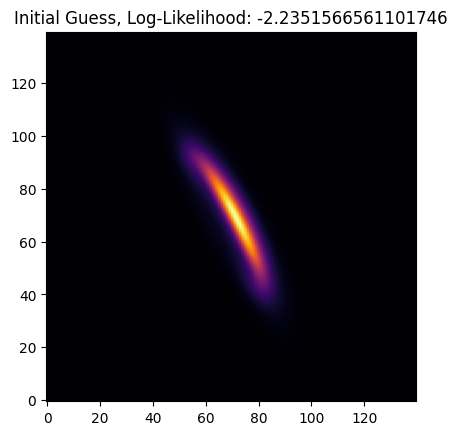

In [12]:
plt.imshow(opt.get_model(), origin='lower', cmap='inferno')
plt.title(f"Initial Guess, Log-Likelihood: {opt.log_likelihood(target_image, err_map)}")

In [13]:
opt.print_params()

Disk Params: {'accuracy': 0.005, 'alpha_in': 5, 'alpha_out': -5, 'sma': 46.0, 'e': 0.0, 'ksi0': 3.0, 'gamma': 2.0, 'beta': 1.0, 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': 80.0, 'position_angle': 27.5, 'x_center': 70.0, 'y_center': 70.0, 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.98480775, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.98480775, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([10.23349036,  2.11937791,  1.        ,  0.60763359,  0.41831628],      dtype=float64)}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 109.62, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': Array(194.0000425, dtype=float64)}


In [14]:
# Can enable these to debug jax issues
# jax.config.update('jax_debug_nans', True)
# jax.config.update('jax_debug_infs', True)

### Running Optimization

In [15]:

# Logscaling helps for fitting across orders of magnitude

fit_keys = ['alpha_in', 'alpha_out', 'sma', 'inclination', 'position_angle', 'x_center', 'y_center', 'knot_values', 'e']
logscaled_params = ['knot_values']
array_params = ['knot_values']
bounds = ([0.1, -15, 0, 0, 0, 60, 60, np.zeros(opt.spf_params["num_knots"]), 0],
          [20, -0.1, 150, 180, 400, 80, 80, 1e4*np.ones(opt.spf_params["num_knots"]), 1])

opt.scipy_bounded_optimize(fit_keys, bounds, logscaled_params, array_params, target_image, err_map, use_grad = True, disp_soln = True, iters = 2000)
optimal_image = opt.get_model()

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 2.1706019560183396
        x: [ 5.492e+00 -3.961e+00 ... -9.903e-01  8.403e-02]
      nit: 12
      jac: [ 1.779e-04  2.741e-03 ...  2.242e-04  1.529e-03]
     nfev: 21
     njev: 21
 hess_inv: <13x13 LbfgsInvHessProduct with dtype=float64>


### Results

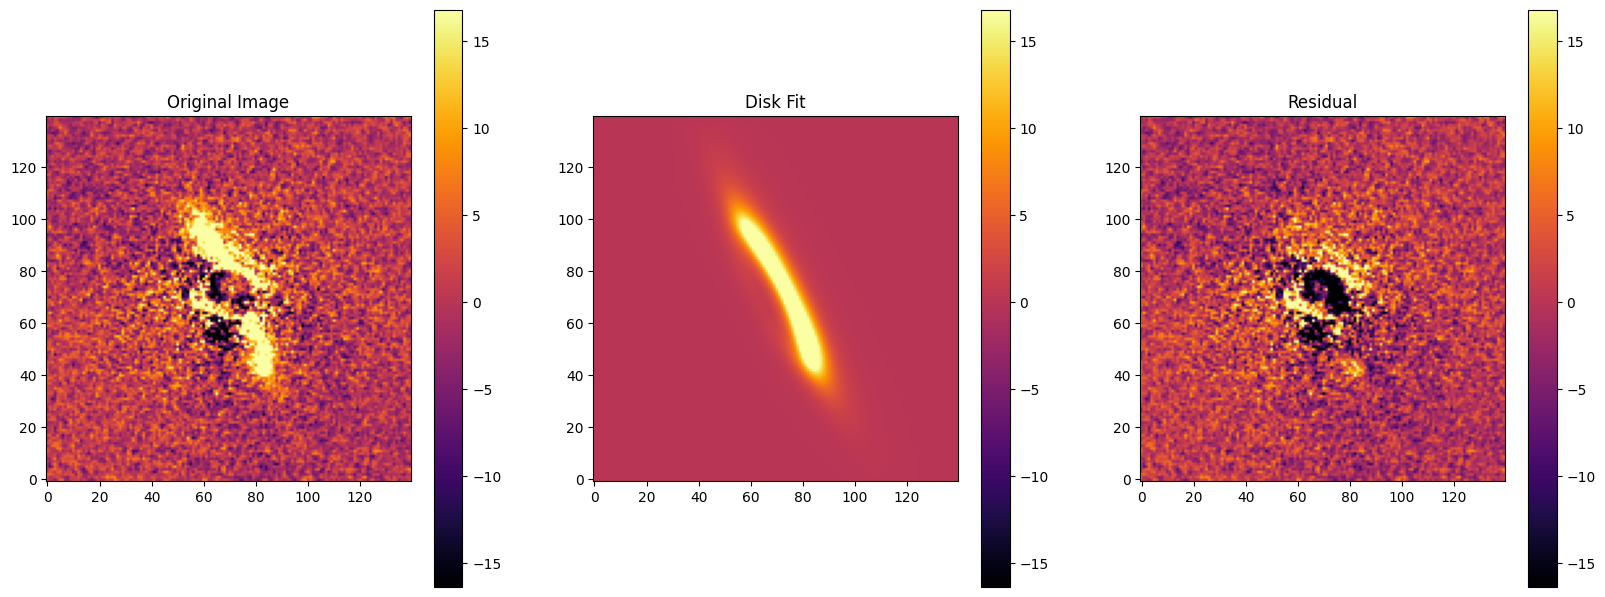

In [16]:
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image[mask], 10)
vmax = np.nanpercentile(target_image[mask], 90)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

In [17]:
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()

Disk Params: {'accuracy': 0.005, 'alpha_in': np.float64(5.491748952843884), 'alpha_out': np.float64(-3.9613137467765034), 'sma': np.float64(46.55708304698246), 'e': np.float64(0.08403225087372201), 'ksi0': 3.0, 'gamma': 2.0, 'beta': 1.0, 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': np.float64(78.86760618688625), 'position_angle': np.float64(26.718662664561585), 'x_center': np.float64(72.23054470986625), 'y_center': np.float64(71.36748236768538), 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.98480775, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.98480775, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([5.71211486, 4.23464677, 1.        , 0.25720476, 0.18233443],      dtype=float64)}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 109.62, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': Array(395.22369914, dtype=float64)}


## Running MCMC

In [18]:
# For MCMC, spline values are log scaled, the optimizer class passes them in as log(spf_params) and they are exponated in the lambda expression, this evens out the markov chains
# helping MCMC work better

fit_keys = ['alpha_in', 'alpha_out', 'sma', 'inclination', 'position_angle', 'x_center', 'y_center', 'knot_values', 'e']
logscaled_params = ['knot_values']
array_params = ['knot_values']
bounds = ([0.1, -15, 0, 0, 0, 60, 60, np.zeros(opt.spf_params["num_knots"]), 0],
          [200, -0.1, 150, 180, 400, 80, 80, 1e4*np.ones(opt.spf_params["num_knots"]), 1])

mc_model = opt.mcmc(fit_keys, logscaled_params, array_params, target_image, err_map, bounds, nwalkers=100, niter=100, burns=20)

Running burn-in...


100%|██████████| 20/20 [00:10<00:00,  1.88it/s]


Running production...


100%|██████████| 100/100 [00:37<00:00,  2.67it/s]


In [19]:
mc_soln = mc_model.get_theta_median(scaled = True)
img = opt.get_model()

Text(0.5, 1.0, 'Post MCMC')

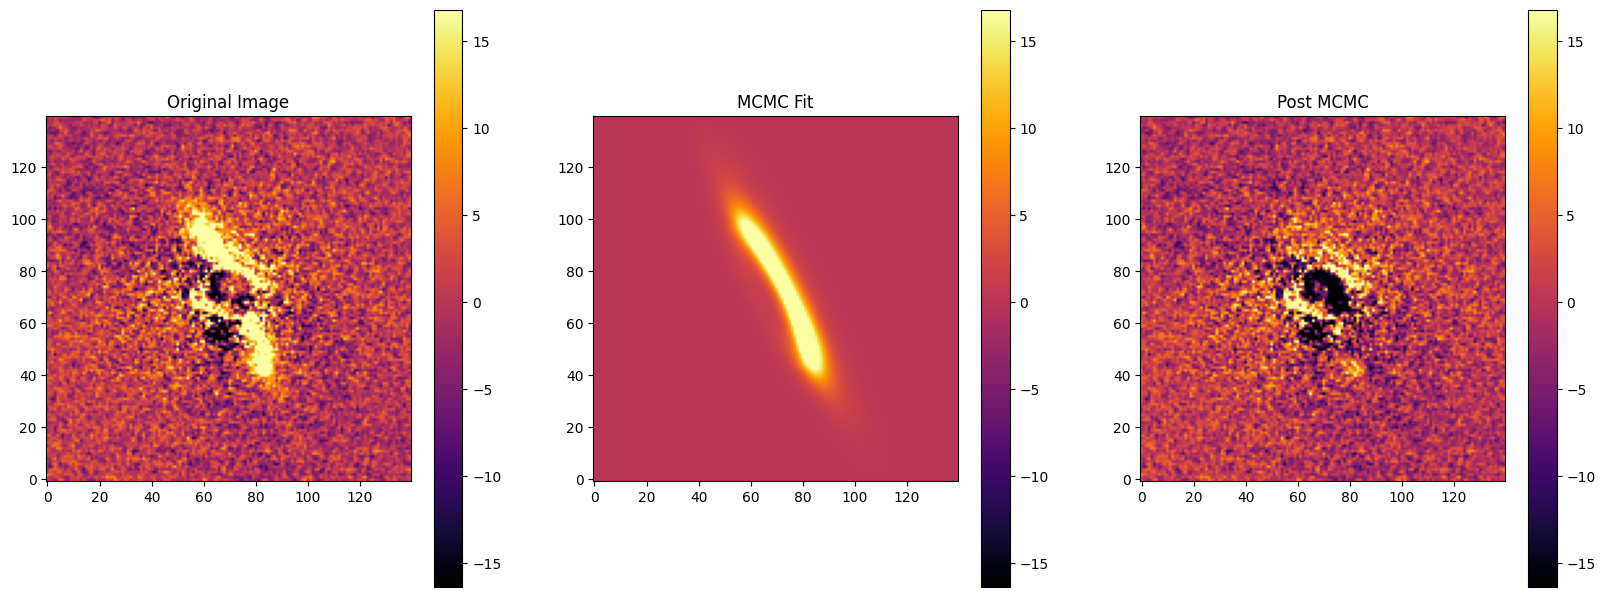

In [20]:
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image[mask], 10)
vmax = np.nanpercentile(target_image[mask], 90)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(img, origin='lower', cmap='inferno')
axes[1].set_title("MCMC Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-img, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)
plt.title("Post MCMC")

### Plotting MCMC Results

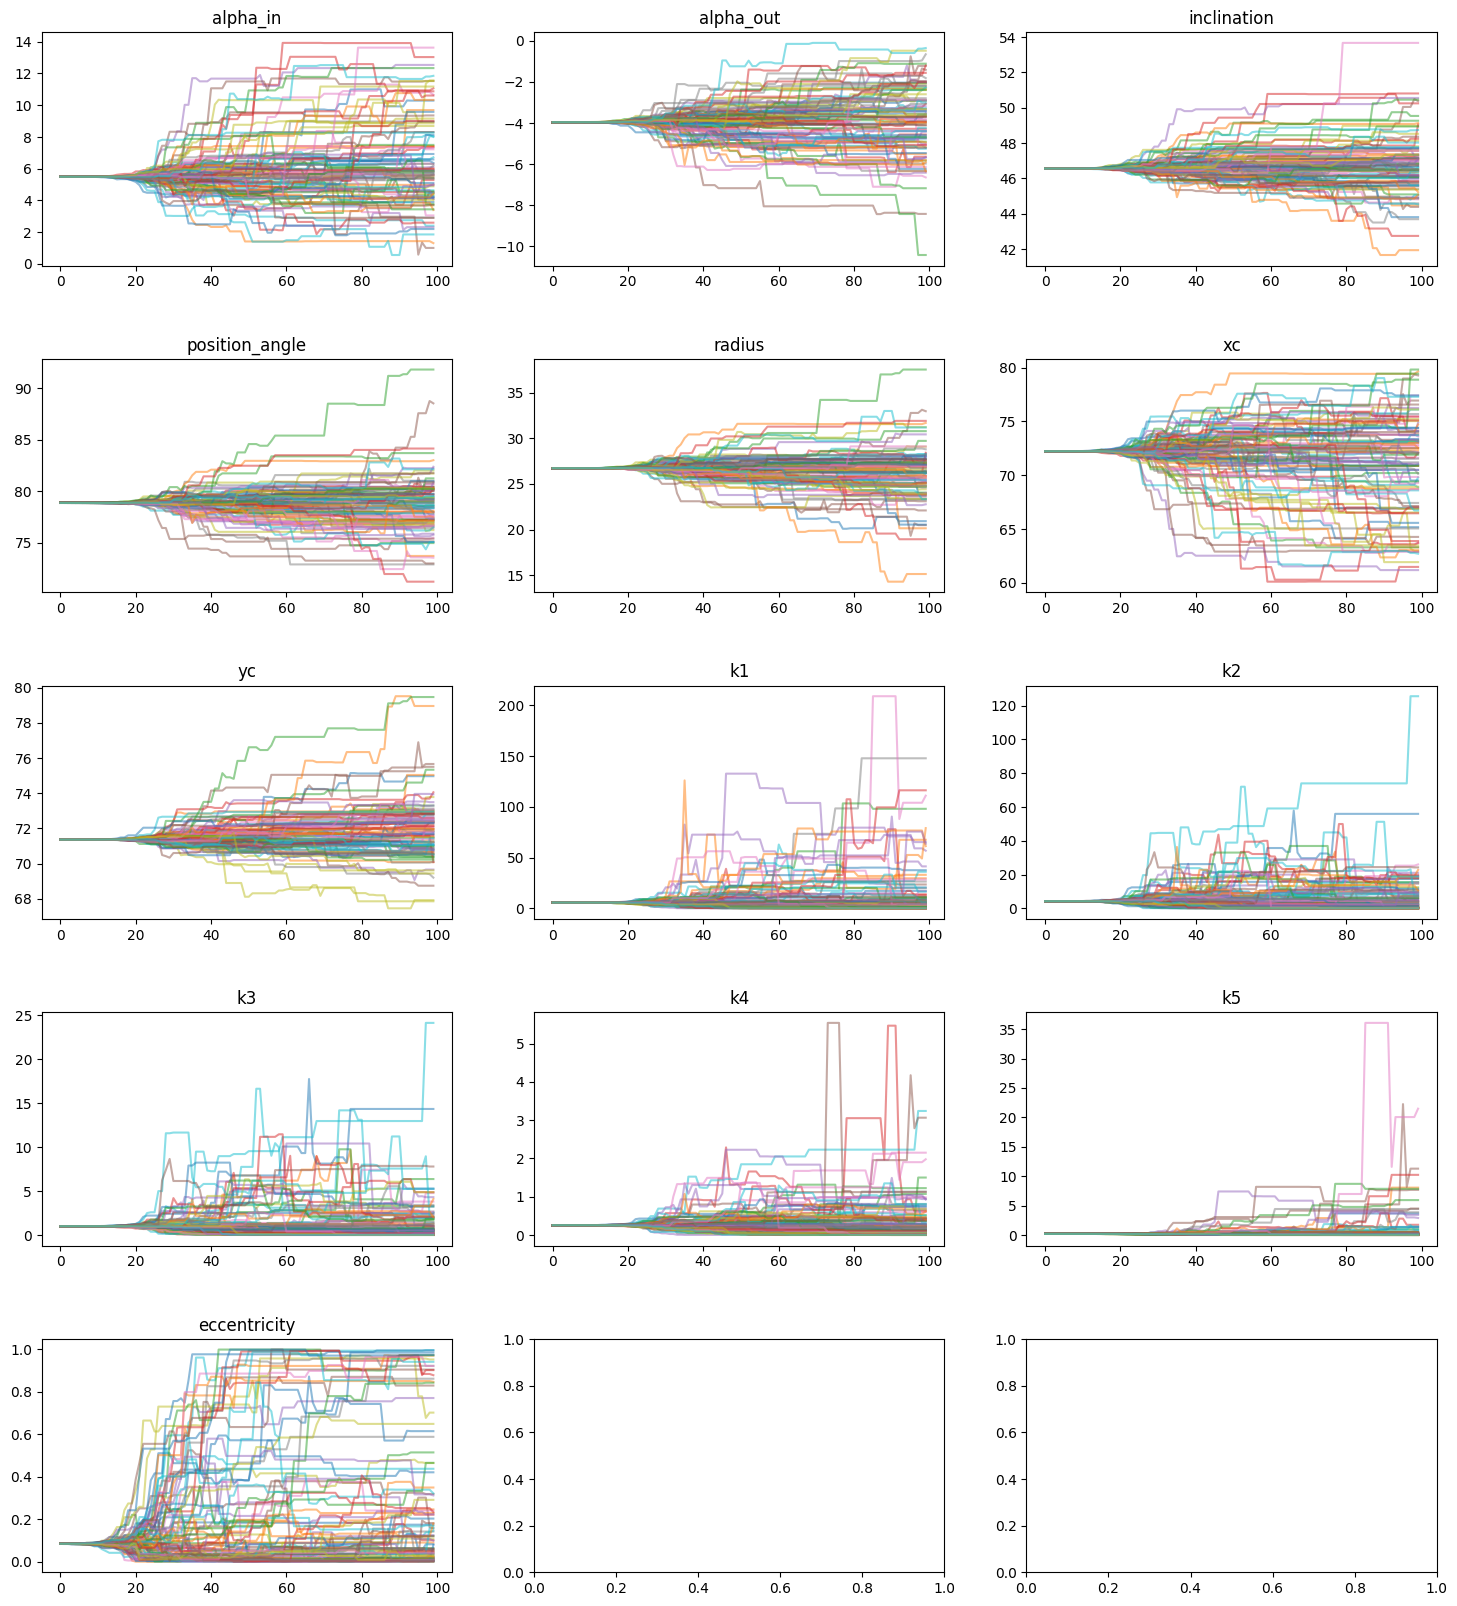

In [21]:
labels = ['alpha_in', 'alpha_out', 'inclination', 'position_angle', 'radius', 'xc', 'yc']
for i in range(0, opt.spf_params['num_knots']):
    labels.append('k'+str(i+1))
labels.append('eccentricity')
mc_model.plot_chains(labels, scaled = True)

### Corner Plot

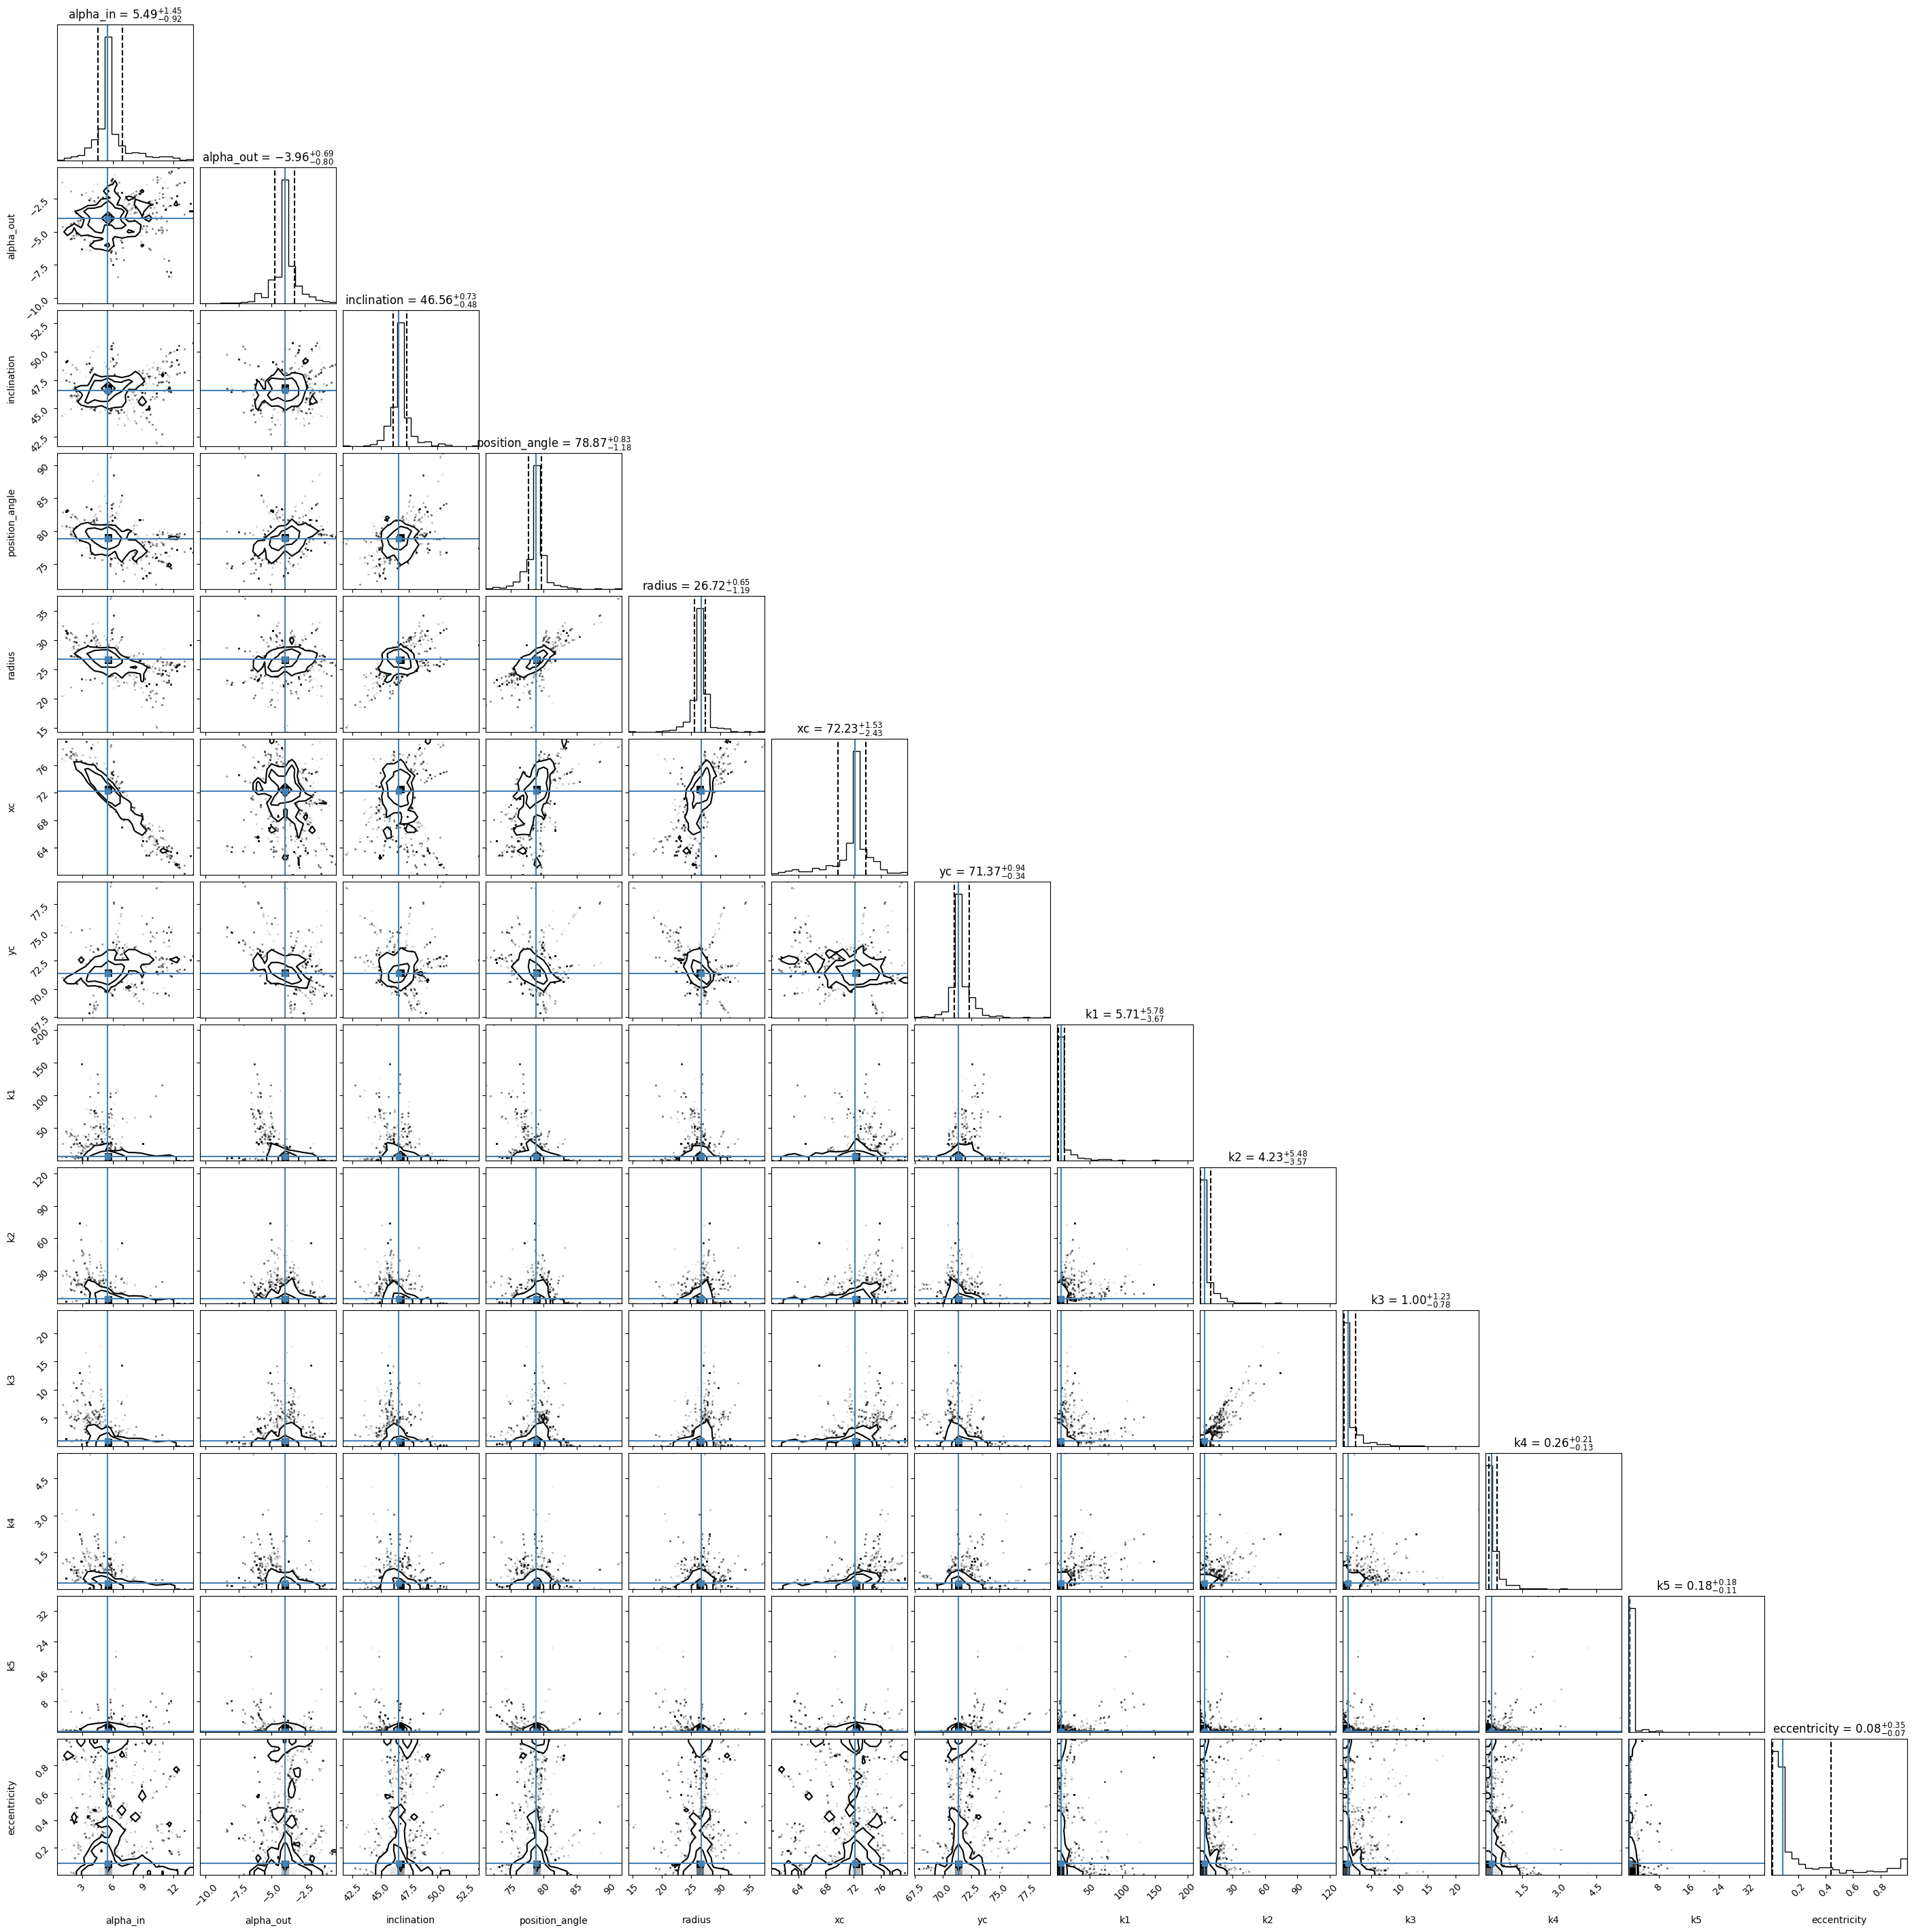

In [22]:
fig = mc_model.show_corner_plot(labels, truths=mc_soln, scaled = True, quiet = True)

In [23]:
print(dict(zip(labels, mc_model.get_theta_median(scaled = True))))

{'alpha_in': np.float64(5.491955751154601), 'alpha_out': np.float64(-3.9612392258529363), 'inclination': np.float64(46.55715569832331), 'position_angle': np.float64(78.86761776400407), 'radius': np.float64(26.718481015944413), 'xc': np.float64(72.23052303888795), 'yc': np.float64(71.36837528812697), 'k1': np.float64(5.711442489825936), 'k2': np.float64(4.233313995201369), 'k3': np.float64(0.999161289667011), 'k4': np.float64(0.2571888098772997), 'k5': np.float64(0.1823306477141115), 'eccentricity': np.float64(0.08395846726228542)}
